# Exjobb Latency Analysis

In [4]:
%pip install numpy matplotlib pandas scipy

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


In [5]:
def get_trace_dataset(expid, runid):
    df = pd.read_csv(f'./traces/old/{expid}/{runid}/{runid}-trace.csv')
    return df


def get_experiment_info(expid):
    info = {}
    with open(f'./traces/old/{expid}/info.txt', 'r') as f:
        for i, line in enumerate(f):
            if i == 7:
                info['Dataplane'] = line.split(':')[1].strip()
            elif i == 8:
                info['Protocol'] = line.split(':')[1].strip()
            elif i == 9:
                info['Policy Direction'] = line.split(':')[1].strip()
            elif i == 10:
                info['Istio Installed'] = line.split(':')[1].strip()
            elif i == 11:
                info['Istio Policy'] = line.split(':')[1].strip()

    return info


def get_experiment_id(exp):
    return exp if isinstance(exp, str) else exp['id']


def get_run_ids(exp, default=('1', '2', '3')):
    if isinstance(exp, dict):
        return exp.get('runs', default)
    return default


def get_delay_key_for_experiment(expid):
    return 'delay' if get_experiment_info(expid)['Protocol'] == 'udp' else 'Delay (s)'


def get_combined_trace_dataset(expid, runids=('1', '2', '3')):
    frames = []
    for runid in runids:
        frames.append(get_trace_dataset(expid, runid).copy())
    return pd.concat(frames, ignore_index=True)


def get_clean_latency_series(df, delay_key='delay', protocol='udp'):
    latencies = df[delay_key]

    # HTTP requests always have a warm up time, remove the first three requests
    if protocol == 'http':
        latencies = latencies.iloc[3:]

    return latencies

    # Remove outliers using IQR method
    Q1 = latencies.quantile(0.25)
    Q3 = latencies.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = max(Q1 - 1.5 * IQR, 0)
    upper_bound = Q3 + 1.5 * IQR
    return latencies[(latencies >= lower_bound) & (latencies <= upper_bound)]


def get_combined_latency_series(exp, delay_key=None):
    expid = get_experiment_id(exp)
    info = get_experiment_info(expid)
    if delay_key is None:
        delay_key = get_delay_key_for_experiment(expid)

    df = get_combined_trace_dataset(expid, get_run_ids(exp))
    return get_clean_latency_series(df, delay_key=delay_key, protocol=info['Protocol'])


def bootstrap_mean_ci(latencies, n_resamples=2000, confidence=0.95, seed=42):
    values = latencies.to_numpy()
    if len(values) == 0:
        return (np.nan, np.nan)

    rng = np.random.default_rng(seed)
    bootstrap_means = rng.choice(values, size=(n_resamples, len(values)), replace=True).mean(axis=1)
    alpha = (1 - confidence) / 2
    return tuple(np.quantile(bootstrap_means, [alpha, 1 - alpha]))


def get_latency_statistics(latencies):
    q1 = latencies.quantile(0.25)
    q3 = latencies.quantile(0.75)
    iqr = q3 - q1
    ci_low, ci_high = bootstrap_mean_ci(latencies)

    return {
        'count': len(latencies),
        'mean': latencies.mean(),
        'median': latencies.median(),
        'std': latencies.std(ddof=1),
        'iqr': iqr,
        'p95': latencies.quantile(0.95),
        'p99': latencies.quantile(0.99),
        'mean_ci_low': ci_low,
        'mean_ci_high': ci_high,
    }


def percentage_change(base_value, new_value):
    return ((new_value - base_value) / base_value) * 100


def format_change(base_value, new_value):
    change = percentage_change(base_value, new_value)
    if change < 0:
        return f"{abs(change):.1f}% faster"
    return f"{change:.1f}% slower"


def summarize_latency_experiments(experiment_ids, delay_key=None):
    rows = []
    for expid in experiment_ids:
        latencies = get_combined_latency_series(expid, delay_key=delay_key)
        stats = get_latency_statistics(latencies)
        info = get_experiment_info(expid)
        rows.append({
            'Experiment': expid,
            'Dataplane': info['Dataplane'],
            'Protocol': info['Protocol'],
            'Policy Direction': info['Policy Direction'],
            'Istio Installed': info['Istio Installed'],
            'Istio Policy': info['Istio Policy'],
            **stats,
        })

    return pd.DataFrame(rows)


def print_latency_summary(experiment_ids, delay_key=None):
    summary = summarize_latency_experiments(experiment_ids, delay_key=delay_key)
    print(summary.to_string(index=False))
    return summary


def print_relative_latency_change(base_exp, compare_exp, label, delay_key=None):
    base_id = get_experiment_id(base_exp)
    compare_id = get_experiment_id(compare_exp)
    base_latencies = get_combined_latency_series(base_exp, delay_key=delay_key)
    compare_latencies = get_combined_latency_series(compare_exp, delay_key=delay_key)
    base_mean = base_latencies.mean()
    compare_mean = compare_latencies.mean()
    change = percentage_change(base_mean, compare_mean)
    if change < 0:
        print(
            f"{label}: {compare_id} is {abs(change):.1f}% faster than {base_id} "
            f"(mean {compare_mean:.6f} vs {base_mean:.6f})"
        )
    else:
        print(
            f"{label}: {compare_id} is {change:.1f}% slower than {base_id} "
            f"(mean {compare_mean:.6f} vs {base_mean:.6f})"
        )


def get_trace_dataset_and_plot(experimentstocompare, axs, index, delay_key='Delay (s)'):
    for exp in experimentstocompare:
        expid = get_experiment_id(exp)
        latencies = get_combined_latency_series(exp, delay_key=delay_key)
        stats = get_latency_statistics(latencies)

        print(
            f"{expid}: mean={stats['mean']:.6f}, median={stats['median']:.6f}, "
            f"std={stats['std']:.6f}, p95={stats['p95']:.6f}, p99={stats['p99']:.6f}"
        )

        sorted_lat = np.sort(latencies)
        p = np.linspace(0, 100, len(sorted_lat))

        axs[index].plot(p, sorted_lat, label=get_experiment_info(expid)['Policy Direction'])

    axs[index].set_xlabel('Percentile')
    if index == 0:
        axs[index].set_ylabel('Latency (s)')
    axs[index].set_title(f"{get_experiment_info(get_experiment_id(experimentstocompare[0]))['Dataplane']}")
    axs[index].grid(True)
    axs[index].legend(loc = "upper left")


def get_trace_dataset_and_plot_istio(experimentstocompare, axs, index, delay_key='Delay (s)'):
    for exp in experimentstocompare:
        expid = get_experiment_id(exp)
        latencies = get_combined_latency_series(exp, delay_key=delay_key)
        stats = get_latency_statistics(latencies)

        print(
            f"{expid}: mean={stats['mean']:.6f}, median={stats['median']:.6f}, "
            f"std={stats['std']:.6f}, p95={stats['p95']:.6f}, p99={stats['p99']:.6f}"
        )

        sorted_lat = np.sort(latencies)
        p = np.linspace(0, 100, len(sorted_lat))

        label = f"Istio: {get_experiment_info(expid)['Istio Installed'].capitalize()} - Policy: {get_experiment_info(expid)['Istio Policy']}"
        axs[index].plot(p, sorted_lat, label=label)

    axs[index].set_xlabel('Percentile')
    if index == 0:
        axs[index].set_ylabel('Latency (s)')
    axs[index].set_title(f"Istio - {get_experiment_info(get_experiment_id(experimentstocompare[0]))['Dataplane']}")
    axs[index].grid(True)
    axs[index].legend()


In [6]:
# Combined-run latency statistics for the experiments used below.
combined_run_experiments = [
    '40634', '40635', '40636', '40637',
    '40725', '40726', '40727', '40728',
    '40638', '40639', '40640', '40641',
    '40729', '40730', '40731', '40732',
    '40659', '40669', '40686', '40687',
    '40733', '40734', '40741', '40742',
]

latency_summary = summarize_latency_experiments(combined_run_experiments)
latency_summary = latency_summary.sort_values(['Protocol', 'Dataplane', 'Experiment']).reset_index(drop=True)
print(latency_summary.to_string(index=False))


Experiment Dataplane Protocol Policy Direction  Istio Installed Istio Policy  count     mean   median      std      iqr      p95      p99  mean_ci_low  mean_ci_high
     40729      ebpf     http             none               no        false   2997 0.000431 0.000448 0.000114 0.000181 0.000574 0.000598     0.000427      0.000435
     40730      ebpf     http          ingress               no        false   2997 0.000433 0.000449 0.000112 0.000176 0.000575 0.000594     0.000429      0.000437
     40731      ebpf     http           egress               no        false   2997 0.000432 0.000450 0.000126 0.000176 0.000573 0.000601     0.000428      0.000437
     40732      ebpf     http             both               no        false   2997 0.000432 0.000447 0.000126 0.000178 0.000572 0.000598     0.000428      0.000437
     40733      ebpf     http             none             with         true   2997 0.001019 0.001027 0.000229 0.000176 0.001188 0.001265     0.001011      0.001027
     40734

In [7]:
# Percentage comparisons phrased with explicit protocol and dataplane names.

def mean_latency(expid):
    return get_combined_latency_series(expid).mean()


def print_udp_dataplane_comparison(policy_label, iptables_expid, ebpf_expid):
    iptables_mean = mean_latency(iptables_expid)
    ebpf_mean = mean_latency(ebpf_expid)
    change = percentage_change(iptables_mean, ebpf_mean)

    if change < 0:
        print(
            f"UDP traffic ({policy_label}): using ebpf is {abs(change):.1f}% faster than iptables "
            f"(mean {ebpf_mean:.6f}s vs {iptables_mean:.6f}s)."
        )
    else:
        print(
            f"UDP traffic ({policy_label}): using ebpf is {change:.1f}% slower than iptables "
            f"(mean {ebpf_mean:.6f}s vs {iptables_mean:.6f}s)."
        )

def print_http_dataplane_comparison(policy_label, iptables_expid, ebpf_expid):
    iptables_mean = mean_latency(iptables_expid)
    ebpf_mean = mean_latency(ebpf_expid)
    change = percentage_change(iptables_mean, ebpf_mean)

    if change < 0:
        print(
            f"HTTP traffic ({policy_label}): using ebpf is {abs(change):.1f}% faster than iptables "
            f"(mean {ebpf_mean:.6f}s vs {iptables_mean:.6f}s)."
        )
    else:
        print(
            f"HTTP traffic ({policy_label}): using ebpf is {change:.1f}% slower than iptables "
            f"(mean {ebpf_mean:.6f}s vs {iptables_mean:.6f}s)."
        )


def print_istio_overhead(dataplane, baseline_expid, istio_expid, scenario_label):
    baseline_mean = mean_latency(baseline_expid)
    istio_mean = mean_latency(istio_expid)
    change = percentage_change(baseline_mean, istio_mean)

    print(
        f"HTTP traffic ({dataplane}, {scenario_label}): with Istio latency increases by {change:.1f}% "
        f"compared with no Istio (mean {istio_mean:.6f}s vs {baseline_mean:.6f}s)."
    )


print('UDP dataplane comparison (combined runs):')
print_udp_dataplane_comparison('none', '40634', '40725')
print_udp_dataplane_comparison('ingress', '40635', '40726')
print_udp_dataplane_comparison('egress', '40636', '40727')
print_udp_dataplane_comparison('both', '40637', '40728')

print('\nHTTP dataplane comparison (combined runs):')
print_http_dataplane_comparison('none', '40638', '40729')
print_http_dataplane_comparison('ingress', '40639', '40730')
print_http_dataplane_comparison('egress', '40640', '40731')
print_http_dataplane_comparison('both', '40641', '40732')



print('\nIstio overhead compared with no-Istio baseline (combined runs):')
print_istio_overhead('iptables', '40638', '40659', 'with policy=false')
print_istio_overhead('iptables', '40638', '40669', 'with policy=true')
print_istio_overhead('iptables', '40638', '40687', 'with acceleration + policy=false')
print_istio_overhead('iptables', '40638', '40686', 'with acceleration + policy=true')
print_istio_overhead('ebpf', '40729', '40734', 'with policy=false')
print_istio_overhead('ebpf', '40729', '40733', 'with policy=true')
print_istio_overhead('ebpf', '40729', '40742', 'with acceleration + policy=false')
print_istio_overhead('ebpf', '40729', '40741', 'with acceleration + policy=true')


UDP dataplane comparison (combined runs):
UDP traffic (none): using ebpf is 6.1% faster than iptables (mean 0.000347s vs 0.000369s).
UDP traffic (ingress): using ebpf is 6.3% faster than iptables (mean 0.000346s vs 0.000369s).
UDP traffic (egress): using ebpf is 6.2% faster than iptables (mean 0.000348s vs 0.000371s).
UDP traffic (both): using ebpf is 6.1% faster than iptables (mean 0.000349s vs 0.000372s).

HTTP dataplane comparison (combined runs):
HTTP traffic (none): using ebpf is 4.1% faster than iptables (mean 0.000431s vs 0.000449s).
HTTP traffic (ingress): using ebpf is 3.3% faster than iptables (mean 0.000433s vs 0.000448s).
HTTP traffic (egress): using ebpf is 3.8% faster than iptables (mean 0.000432s vs 0.000450s).
HTTP traffic (both): using ebpf is 4.8% faster than iptables (mean 0.000432s vs 0.000454s).

Istio overhead compared with no-Istio baseline (combined runs):
HTTP traffic (iptables, with policy=false): with Istio latency increases by 125.7% compared with no Istio (

# UDP

Mean Latencies iptables, udp:
40634: mean=0.000369, median=0.000367, std=0.000118, p95=0.000546, p99=0.000590
40635: mean=0.000369, median=0.000366, std=0.000124, p95=0.000551, p99=0.000595
40636: mean=0.000371, median=0.000369, std=0.000132, p95=0.000550, p99=0.000592
40637: mean=0.000372, median=0.000369, std=0.000128, p95=0.000548, p99=0.000595

Mean Latencies ebpf, udp:
40725: mean=0.000347, median=0.000346, std=0.000107, p95=0.000508, p99=0.000544
40726: mean=0.000346, median=0.000347, std=0.000113, p95=0.000505, p99=0.000542
40727: mean=0.000348, median=0.000347, std=0.000113, p95=0.000510, p99=0.000553
40728: mean=0.000349, median=0.000348, std=0.000109, p95=0.000507, p99=0.000546


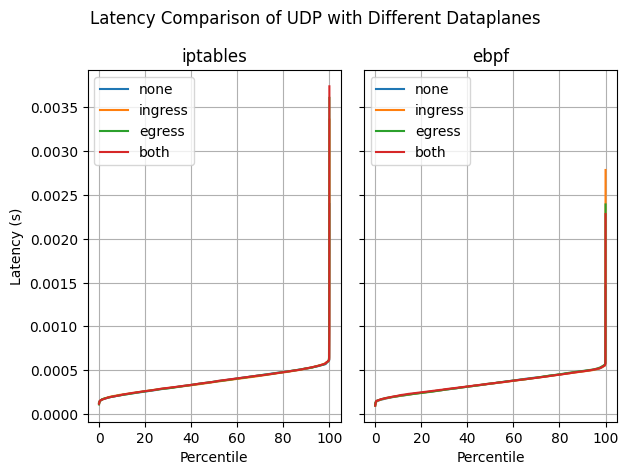

In [8]:
fig, axs = plt.subplots(1,2,sharey=True)
fig.suptitle('Latency Comparison of UDP with Different Dataplanes')

experimentstocompare = ['40634', '40635', '40636', '40637']
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
get_trace_dataset_and_plot(experimentstocompare, axs, index = 0, delay_key = "delay")

experimentstocompare = ['40725', '40726', '40727', '40728']
print(f"\nMean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
get_trace_dataset_and_plot(experimentstocompare, axs, index = 1, delay_key = "delay")

plt.tight_layout()
plt.savefig('plots/latency_comparison_udp.pdf', format='pdf')
plt.show()

# HTTP

Mean Latencies iptables, http:
40638: mean=0.000449, median=0.000466, std=0.000124, p95=0.000592, p99=0.000619
40639: mean=0.000448, median=0.000465, std=0.000103, p95=0.000595, p99=0.000617
40640: mean=0.000450, median=0.000462, std=0.000137, p95=0.000593, p99=0.000622
40641: mean=0.000454, median=0.000475, std=0.000106, p95=0.000596, p99=0.000618
Mean Latencies ebpf, http:
40729: mean=0.000431, median=0.000448, std=0.000114, p95=0.000574, p99=0.000598
40730: mean=0.000433, median=0.000449, std=0.000112, p95=0.000575, p99=0.000594
40731: mean=0.000432, median=0.000450, std=0.000126, p95=0.000573, p99=0.000601
40732: mean=0.000432, median=0.000447, std=0.000126, p95=0.000572, p99=0.000598


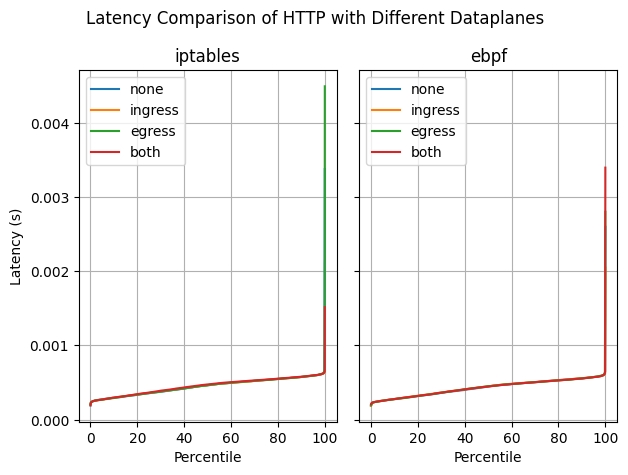

In [9]:
fig, axs = plt.subplots(1,2,sharey=True)
fig.suptitle('Latency Comparison of HTTP with Different Dataplanes')

experimentstocompare = ['40638', '40639', '40640', '40641']
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
get_trace_dataset_and_plot(experimentstocompare, axs, index = 0)

experimentstocompare = ['40729', '40730', '40731', '40732']
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
get_trace_dataset_and_plot(experimentstocompare, axs, index = 1)

plt.tight_layout()
plt.savefig('plots/latency_comparison_http.pdf', format='pdf')
plt.show()

## Istio

Mean Latencies Istio - iptables, http:
40638: mean=0.000449, median=0.000466, std=0.000124, p95=0.000592, p99=0.000619
40659: mean=0.001014, median=0.001019, std=0.000216, p95=0.001184, p99=0.001258
40669: mean=0.001029, median=0.001031, std=0.000254, p95=0.001192, p99=0.001262
40687: mean=0.001027, median=0.001033, std=0.000210, p95=0.001205, p99=0.001267
40686: mean=0.001042, median=0.001047, std=0.000211, p95=0.001220, p99=0.001292
Mean Latencies Istio - ebpf, http:
40729: mean=0.000431, median=0.000448, std=0.000114, p95=0.000574, p99=0.000598
40734: mean=0.001004, median=0.001010, std=0.000222, p95=0.001172, p99=0.001242
40733: mean=0.001019, median=0.001027, std=0.000229, p95=0.001188, p99=0.001265
40742: mean=0.001014, median=0.001015, std=0.000219, p95=0.001189, p99=0.001257
40741: mean=0.001028, median=0.001031, std=0.000240, p95=0.001200, p99=0.001269


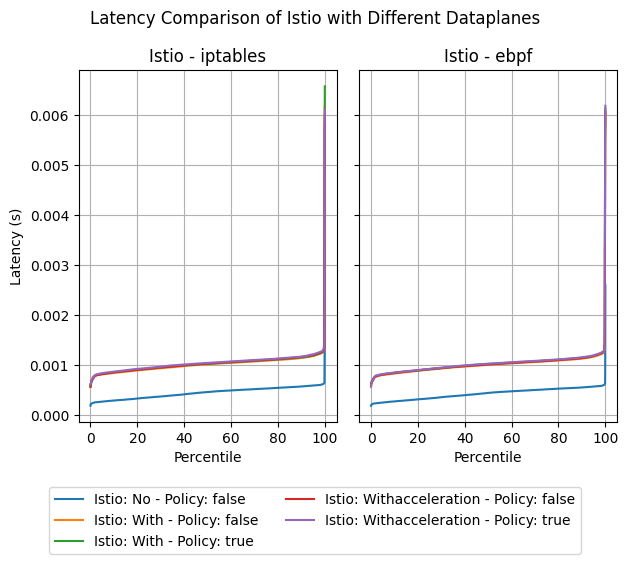

In [10]:
fig, axs = plt.subplots(1, 2,sharey=True)
fig.suptitle('Latency Comparison of Istio with Different Dataplanes')

experimentstocompare = ['40638', '40659', '40669', '40687', '40686']
print(f"Mean Latencies Istio - {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
get_trace_dataset_and_plot_istio(experimentstocompare, axs, index = 0)


experimentstocompare = ['40729', '40734', '40733', '40742', '40741']
print(f"Mean Latencies Istio - {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
get_trace_dataset_and_plot_istio(experimentstocompare, axs, index = 1)

fig.legend(axs[0].get_legend_handles_labels()[0], axs[0].get_legend_handles_labels()[1], loc='upper center', bbox_to_anchor=(0.5, 0), ncol=2)
axs[0].get_legend().remove()  # Remove legend from the first subplot
axs[1].get_legend().remove()  # Remove legend from the second subplot
plt.tight_layout()
plt.savefig('plots/latency_comparison_istio.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Significance testing

## eBPF vs iptables: 
$H_0$ : eBPF latency is not lower than iptables

$H_1$ : eBPF latency is lower than iptables.

In [11]:
from scipy.stats import ttest_ind


def pooled_latencies(experiment_ids, delay_key=None):
    return pd.concat(
        [get_combined_latency_series(expid, delay_key=delay_key) for expid in experiment_ids],
        ignore_index=True,
    )


def welch_one_sided_ttest(base_sample, compare_sample):
    test_result = ttest_ind(base_sample, compare_sample, equal_var=False)
    one_sided_p = test_result.pvalue / 2 if test_result.statistic > 0 else 1 - (test_result.pvalue / 2)
    return test_result.statistic, one_sided_p


iptables_udp = ['40634', '40635', '40636', '40637']
ebpf_udp = ['40725', '40726', '40727', '40728']
iptables_http = ['40638', '40639', '40640', '40641']
ebpf_http = ['40729', '40730', '40731', '40732']

iptables_all = pooled_latencies(iptables_udp + iptables_http)
ebpf_all = pooled_latencies(ebpf_udp + ebpf_http)
iptables_udp_latencies = pooled_latencies(iptables_udp, delay_key='delay')
ebpf_udp_latencies = pooled_latencies(ebpf_udp, delay_key='delay')
iptables_http_latencies = pooled_latencies(iptables_http)
ebpf_http_latencies = pooled_latencies(ebpf_http)

print(latency_summary)
print()
print('Welch one-sided t-test (H1: eBPF latency is lower than iptables latency)')

for label, iptables_sample, ebpf_sample in [
    ('Overall', iptables_all, ebpf_all),
    ('UDP', iptables_udp_latencies, ebpf_udp_latencies),
    ('HTTP', iptables_http_latencies, ebpf_http_latencies),
]:
    statistic, p_value = welch_one_sided_ttest(iptables_sample, ebpf_sample)
    iptables_mean = iptables_sample.mean()
    ebpf_mean = ebpf_sample.mean()
    conclusion = 'reject H0' if p_value < 0.05 else 'fail to reject H0'
    print(
        f"{label}: t={statistic:.4f}, one-sided p={p_value:.6g}, "
        f"iptables mean={iptables_mean:.6f}s, ebpf mean={ebpf_mean:.6f}s -> {conclusion}"
    )


   Experiment Dataplane Protocol Policy Direction   Istio Installed  \
0       40729      ebpf     http             none                no   
1       40730      ebpf     http          ingress                no   
2       40731      ebpf     http           egress                no   
3       40732      ebpf     http             both                no   
4       40733      ebpf     http             none              with   
5       40734      ebpf     http             none              with   
6       40741      ebpf     http             none  withacceleration   
7       40742      ebpf     http             none  withacceleration   
8       40638  iptables     http             none                no   
9       40639  iptables     http          ingress                no   
10      40640  iptables     http           egress                no   
11      40641  iptables     http             both                no   
12      40659  iptables     http             none              with   
13    

# Network policy significance testing

## No Istio only

We test whether enabling a network policy increases latency compared with the no-policy baseline.

$H_0$ : network policies do not increase latency.

$H_1$ : network policies increase latency.

In [12]:
no_istio_experiments = {
    ('iptables', 'udp'): {
        'none': '40634',
        'ingress': '40635',
        'egress': '40636',
        'both': '40637',
    },
    ('ebpf', 'udp'): {
        'none': '40725',
        'ingress': '40726',
        'egress': '40727',
        'both': '40728',
    },
    ('iptables', 'http'): {
        'none': '40638',
        'ingress': '40639',
        'egress': '40640',
        'both': '40641',
    },
    ('ebpf', 'http'): {
        'none': '40729',
        'ingress': '40730',
        'egress': '40731',
        'both': '40732',
    },
}

rows = []
for (dataplane, protocol), experiments in no_istio_experiments.items():
    baseline_exp = experiments['none']
    baseline_delay_key = 'delay' if protocol == 'udp' else 'Delay (s)'
    baseline_latencies = pooled_latencies([baseline_exp], delay_key=baseline_delay_key)

    for policy in ['ingress', 'egress', 'both']:
        policy_exp = experiments[policy]
        policy_latencies = pooled_latencies([policy_exp], delay_key=baseline_delay_key)
        statistic, p_value = welch_one_sided_ttest(policy_latencies, baseline_latencies)
        conclusion = 'reject H0' if p_value < 0.05 else 'fail to reject H0'
        rows.append({
            'Dataplane': dataplane,
            'Protocol': protocol,
            'Policy Direction': policy,
            'Baseline Experiment': baseline_exp,
            'Policy Experiment': policy_exp,
            'Baseline Mean': baseline_latencies.mean(),
            'Policy Mean': policy_latencies.mean(),
            't-statistic': statistic,
            'one-sided p-value': p_value,
            'Conclusion': conclusion,
        })

policy_test_summary = pd.DataFrame(rows).sort_values(['Protocol', 'Dataplane', 'Policy Direction']).reset_index(drop=True)
print('Welch one-sided t-test (H1: network policy increases latency; no Istio only)')
print(policy_test_summary.to_string(index=False))


Welch one-sided t-test (H1: network policy increases latency; no Istio only)
Dataplane Protocol Policy Direction Baseline Experiment Policy Experiment  Baseline Mean  Policy Mean  t-statistic  one-sided p-value        Conclusion
     ebpf     http             both               40729             40732       0.000431     0.000432     0.444528           0.328338 fail to reject H0
     ebpf     http           egress               40729             40731       0.000431     0.000432     0.482374           0.314779 fail to reject H0
     ebpf     http          ingress               40729             40730       0.000431     0.000433     0.844294           0.199270 fail to reject H0
 iptables     http             both               40638             40641       0.000449     0.000454     1.638785           0.050656 fail to reject H0
 iptables     http           egress               40638             40640       0.000449     0.000450     0.119984           0.452250 fail to reject H0
 iptables  